In [1]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.impute import SimpleImputer

C:\Users\marie\AppData\Local\Temp\ipykernel_71512\1389390065.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv(r"C:\Users\marie\rep_codes\udder_project\udder_analysis\long_format_df\lactation_features.csv")

In [3]:
df.columns

Index(['cow', 'vol_udder', 'vol_lf', 'vol_rf', 'vol_lb', 'vol_rb',
       'sarea_udder', 'sarea_lf', 'sarea_rf', 'sarea_lb', 'sarea_rb',
       'eu_front', 'eu_back', 'eu_right', 'eu_left', 'gd_front', 'gd_back',
       'gd_right', 'gd_left', 'peri_udder', 'area_udder', 'circ_udder',
       'exc_udder', 'peri_lf', 'area_lf', 'circ_lf', 'exc_lf', 'peri_rf',
       'area_rf', 'circ_rf', 'exc_rf', 'peri_lb', 'area_lb', 'circ_lb',
       'exc_lb', 'peri_rb', 'area_rb', 'circ_rb', 'exc_rb', 'len_lf', 'len_rf',
       'len_lb', 'len_rb', 'animal_number', 'min_date', 'max_date',
       'count_date', 'min_dim', 'max_dim', 'lactation',
       'milk_flow_duration_mean', 'yield_visit_mean', 'yield_lf_visit_mean',
       'yield_lr_visit_mean', 'yield_rr_visit_mean', 'yield_rf_visit_mean',
       'peak_flow_rf_mean', 'peak_flow_lf_mean', 'peak_flow_rr_mean',
       'peak_flow_lr_mean', 'notmilk_visit_duration_mean',
       'notmilk_visit_duration_std', 'interval_sec_mean', 'kickoff_lf_sum',
       

In [37]:
df["min_teat"] = [np.nanmin(df.loc[i, ["len_rf", "len_rb", "len_lf", "len_lb"]].values.astype('float')) for i in df.index]
df["max_teat"]= [np.nanmax(df.loc[i, ["len_rf", "len_rb", "len_lf", "len_lb"]].values.astype('float')) for i in df.index]
df["max_eu"] = [np.nanmin(df.loc[i, ["eu_front", "eu_right", "eu_back", "eu_left"]].values.astype('float')) for i in df.index]
df["min_eu"] = [np.nanmax(df.loc[i, ["eu_front", "eu_right", "eu_back", "eu_left"]].values.astype('float')) for i in df.index]

C:\Users\marie\AppData\Local\Temp\ipykernel_71512\1794345118.py:1: RuntimeWarning: All-NaN slice encountered
  df["min_teat"] = [np.nanmin(df.loc[i, ["len_rf", "len_rb", "len_lf", "len_lb"]].values.astype('float')) for i in df.index]
C:\Users\marie\AppData\Local\Temp\ipykernel_71512\1794345118.py:2: RuntimeWarning: All-NaN slice encountered
  df["max_teat"]= [np.nanmax(df.loc[i, ["len_rf", "len_rb", "len_lf", "len_lb"]].values.astype('float')) for i in df.index]


In [38]:
X = df[["min_teat", "max_teat","max_eu", "min_eu", "lactation"]]
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(X)
X = imp.transform(X)
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)

C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

Distortion values:
1 : 110.41503379707734
2 : 74.51707439298953
3 : 57.90689945858263
4 : 51.56140316663458
5 : 49.067157472401135
6 : 41.69596166724136
7 : 39.079309805847565
8 : 34.186796019838354
9 : 32.50465777142699


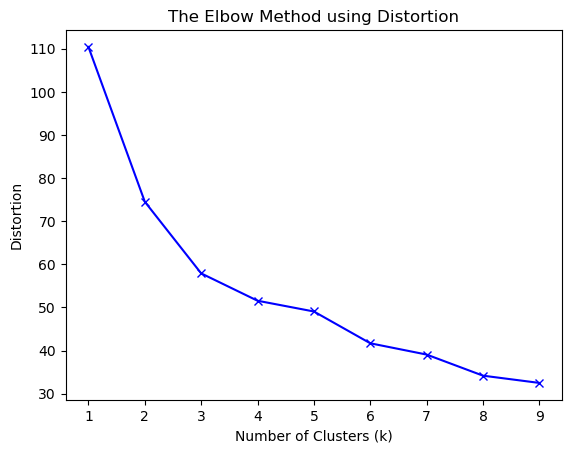

In [39]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    
    inertias.append(kmeanModel.inertia_)
    
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

In [72]:
kmeans = KMeans(n_clusters=4, random_state=5, n_init="auto").fit(X)
df["cluster"] = [str(clus) for clus in kmeans.labels_]
df.to_csv("cluster\cluster_df.csv", index = False)

C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: xlabel='min_teat', ylabel='kickoff_any_sum'>

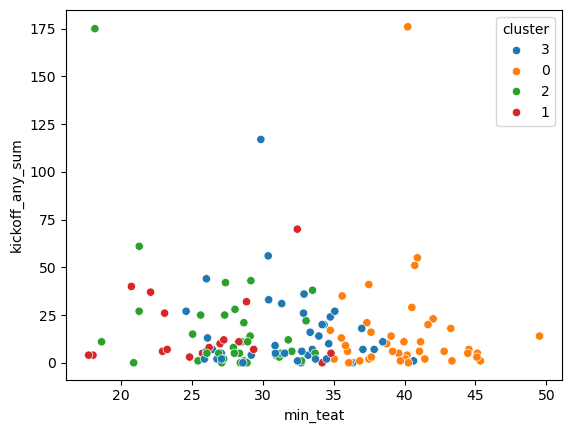

In [58]:
sns.scatterplot(x = df.min_teat, y = df.kickoff_any_sum, hue = df.cluster)

<Axes: xlabel='cluster', ylabel='kickoff_any_sum'>

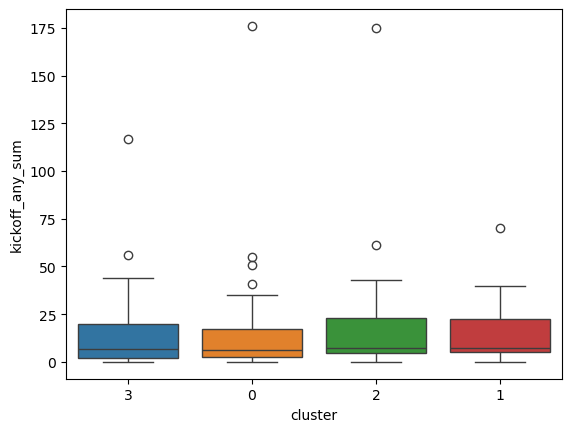

In [59]:
sns.boxplot(x = df.cluster, y = df.kickoff_any_sum, hue = df.cluster)

<Axes: xlabel='cluster', ylabel='min_teat'>

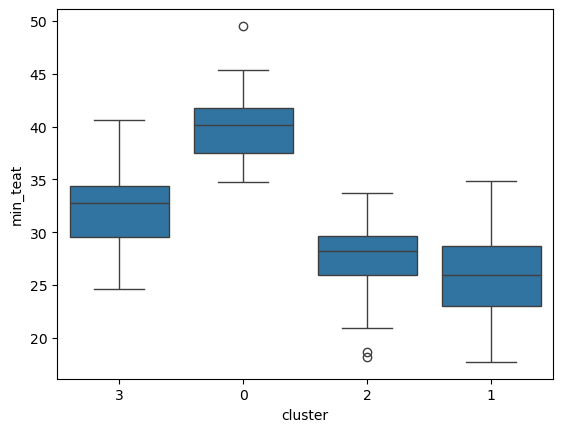

In [57]:
sns.boxplot(x = df.cluster, y = df.min_teat)

<Axes: xlabel='cluster', ylabel='min_eu'>

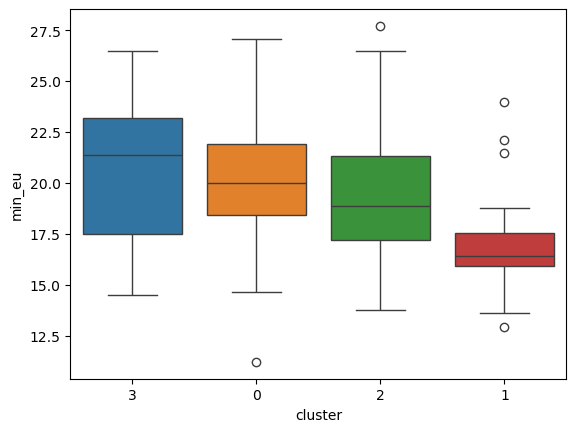

In [60]:
sns.boxplot(x = df.cluster, y = df.min_eu, hue = df.cluster)

<Axes: xlabel='cluster', ylabel='max_eu'>

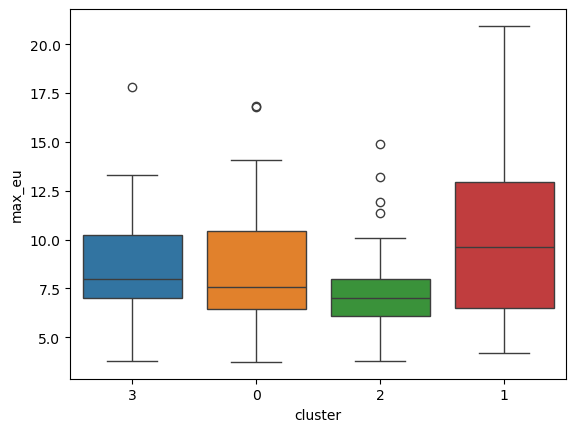

In [61]:
sns.boxplot(x = df.cluster, y = df.max_eu, hue = df.cluster)

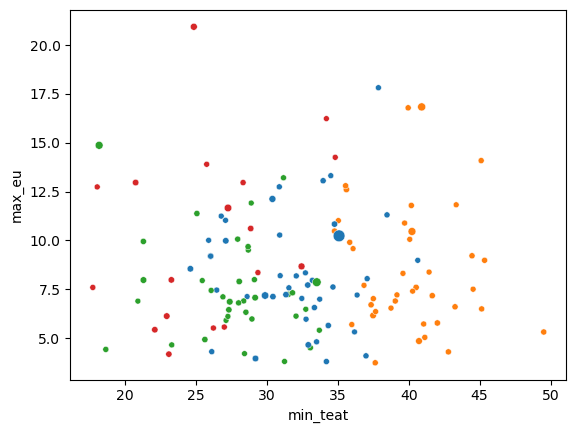

In [79]:
fig, ax = plt.subplots()
sns.scatterplot(x = df.min_teat, y = df.max_eu, hue = df.cluster, size = df.kickoff_any_perc)
ax.get_legend().set_visible(False)

In [73]:
df[df.min_teat > 45]

,cow,vol_udder,vol_lf,vol_rf,vol_lb,vol_rb,sarea_udder,sarea_lf,sarea_rf,sarea_lb,...,yield_lf_visit_sum,yield_lr_visit_sum,yield_rr_visit_sum,yield_rf_visit_sum,interval_visit_mean,min_teat,max_teat,max_eu,min_eu,cluster
3,736,8.529069,5.034365,1.684315,1.298735,0.676856,2190.923732,1036.329523,415.856293,525.530135,...,2524.63,3707.99,4089.27,2908.86,34144.249688,49.515135,51.872415,5.309200,23.348998,0
22,981,NaN,3.721668,NaN,0.958525,NaN,2247.113934,695.148242,923.004505,311.995677,...,264.86,276.81,233.98,268.74,27662.736842,45.345177,55.533931,8.981211,22.737645,0
80,1295,4.387696,NaN,NaN,0.708766,1.062420,2272.688440,NaN,NaN,NaN,...,0.00,2008.82,2197.83,1003.99,31865.185676,45.138132,51.486643,6.491649,19.168391,0
86,1321,9.825822,3.076836,1.859932,NaN,NaN,2525.528124,731.912539,589.460434,612.309925,...,890.36,902.73,1095.26,1021.15,31951.788991,45.104245,45.104245,14.087270,14.659298,0


<Axes: xlabel='max_teat', ylabel='max_eu'>

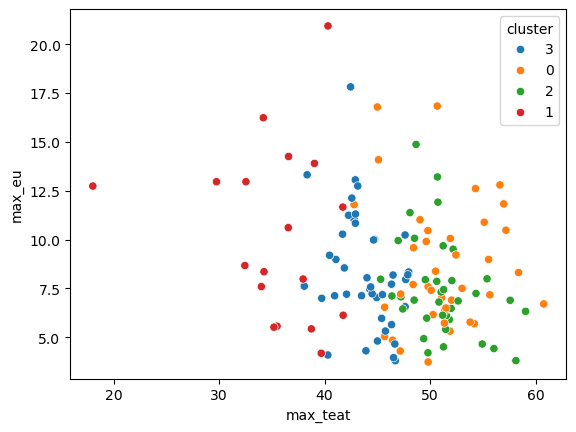

In [63]:
sns.scatterplot(x = df.max_teat, y = df.max_eu, hue = df.cluster)

<Axes: xlabel='min_teat', ylabel='min_eu'>

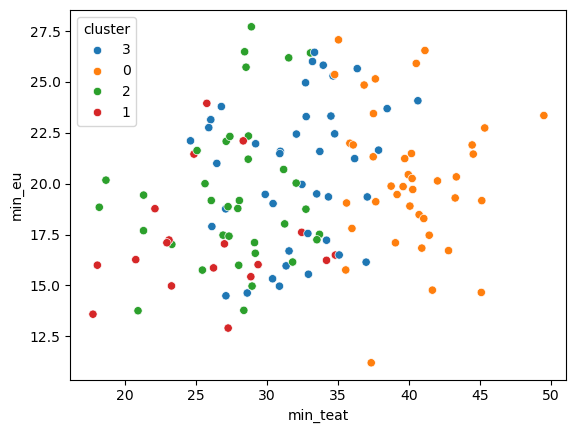

In [64]:
sns.scatterplot(x = df.min_teat, y = df.min_eu, hue = df.cluster)

<Axes: xlabel='min_teat', ylabel='max_eu'>

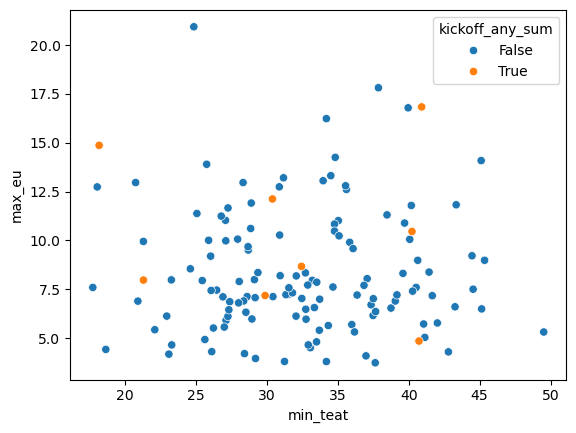

In [71]:
sns.scatterplot(x = df.min_teat, y = df.max_eu, hue =  df.kickoff_any_sum>50)

<Axes: xlabel='cluster', ylabel='kickoff_any_sum'>

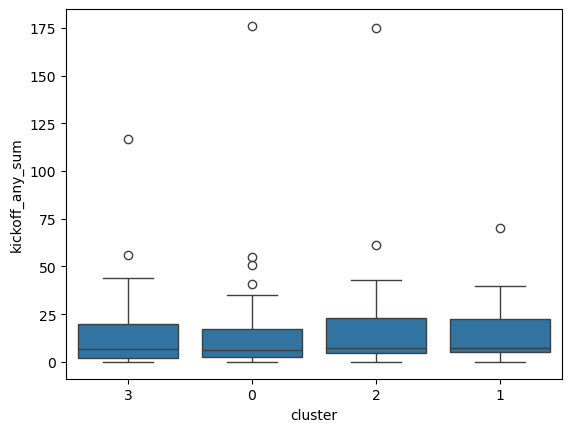

In [66]:
sns.boxplot(x = df.cluster, y = df.kickoff_any_sum)